In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [24]:
data = pd.read_csv("Salary_dataset.csv")
data = data.drop(columns=['Unnamed: 0'])
print(data.head())

   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [26]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


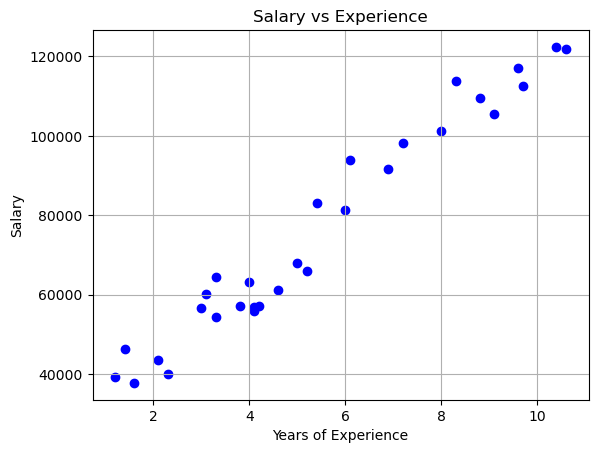

In [27]:
plt.scatter(data['YearsExperience'], data['Salary'], color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.grid(True)
plt.show()

In [28]:
X = data['YearsExperience'].values.reshape(-1, 1)
y = data['Salary'].values.reshape(-1, 1)

In [29]:
# Mean Normalization and Feature scaling

In [30]:
X_mean = np.mean(X)
X_std = np.std(X)
X = (X - X_mean) / X_std


y_mean = np.mean(y)
y_std = np.std(y)
y = (y - y_mean) / y_std

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
class SimpleLinearRegression:
    def __init__(self):
        self.slope = 0
        self.intercept = 0

    def fit(self, X, y):
        x_mean = np.mean(X)
        y_mean = np.mean(y)
        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)
        self.slope = numerator / denominator
        self.intercept = y_mean - self.slope * x_mean

    def predict(self, X):
        return self.slope * X + self.intercept

    def mean_absolute_error(self,y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def mean_squared_error(self,y_true, y_pred):
        return np.mean((y_true - y_pred)**2)

    def root_mean_squared_error(self, y_true, y_pred):
        return np.sqrt(self.mean_squared_error(y_true, y_pred))

    def r2_score(self, y_true, y_pred):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (ss_res / (ss_tot + 1e-10))  


In [42]:
model = SimpleLinearRegression()
model.fit(X_train, y_train)

In [43]:
y_test_pred = model.predict(X_test)


In [44]:
y_test_pred

array([[ 1.47613439],
       [-0.16712845],
       [ 0.98665184],
       [-0.0272763 ],
       [-0.76150012],
       [-0.58668493]])

In [48]:
print("Linear Regression Results:")
print(f"Slope (m): {model.slope:.5f}")
print(f"Intercept (c): {model.intercept:.5f}")
print(f"Mean Squared Error (MSE): {model.mean_squared_error(y_test,y_test_pred):.5f}")
print(f"Mean Squared Error (MSE): {model.mean_absolute_error(y_test,y_test_pred):.5f}")
print("RMSE:", model.root_mean_squared_error(y_test,y_test_pred))
print("R²:", model.r2_score(y_test, y_test_pred))

Linear Regression Results:
Slope (m): 0.97553
Intercept (c): -0.02261
Mean Squared Error (MSE): 0.06859
Mean Squared Error (MSE): 0.23323
RMSE: 0.2618956451815691
R²: 0.9024461774203624


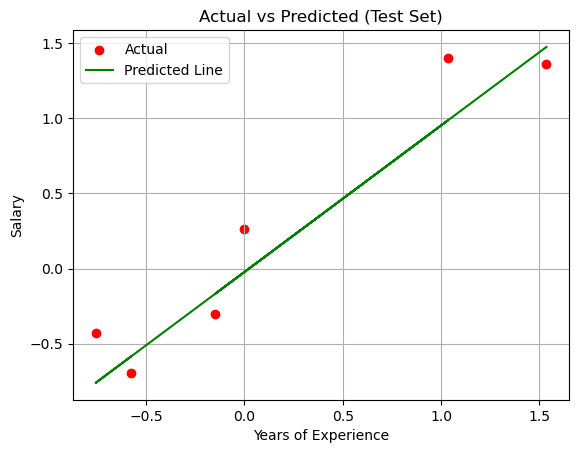

In [37]:
plt.scatter(X_test, y_test, color='red', label='Actual')
plt.plot(X_test, y_test_pred, color='green', label='Predicted Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.grid(True)
plt.show()